In [82]:
import os
import pandas as pd
import numpy as np

stock_id = "8027"

# 讀取評分-----------------------------
folder_path = "stock_news/"+stock_id+"/"+stock_id+"_response"

# 獲取文件夾中的所有文件名列表
files = os.listdir(folder_path)
sorted_files = sorted(files)
response = []

for i in range(len(sorted_files)):
    with open(folder_path + "/" + sorted_files[i], "r") as f:
        try:
            data = f.read()
            print(data)
            response.append([sorted_files[i].split('_')[1], int(data)])
        except:
            pass

response_np = np.array(response)

# 讀取價格-----------------------------
df_csv = pd.read_csv("price_history/"+stock_id+"_price.csv")
price = df_csv.to_numpy()

for i in range(len(price)):
    original_date = price[i][0]
    # 提取年份、月份和日期部分
    year = '20' + original_date[1:3]  # 從索引 0 到索引 2，不包括索引 2
    month = original_date[4:6]  # 從索引 3 到索引 5，不包括索引 5
    day = original_date[7:]  # 從索引 6 到字符串的結尾
    # 將提取的部分組合為新的日期格式
    formatted_date = year + month + day
    price[i][0] = formatted_date
    
price_np = np.flip(np.array(price), axis=0)

# print(response_np)
# print(len(response_np))
# print(price_np)
# print(len(price_np))

# 合併-----------------------------
price_with_signal = []
signal = 0
for i, itemi in enumerate(price_np):
    for j, itemj in enumerate(response_np):
        if itemi[0] == itemj[0]:
            try:
                price_with_signal.append([itemi[0], price_np[i + 1,1], int(itemj[1])])
            except:
                pass
            
print(price_with_signal)

文章內容不明確，無法打分。
53
80分
50分
50
0
30分
50分
80
這篇文章沒有包含情緒相關的內容，因此無法評分。
這篇文章沒有提供任何情緒相關的內容，因此無法評分。
**文章情緒評分：75**

這篇文章傳達的情緒整體上是正面的。它強調了積極的方面，例如希望、可能性和個人成長。文章中也包含一些鼓勵和激勵的語句，有助於提升讀者的情緒。
50
由於提供的文章中沒有任何情緒表達，因此無法評分。
50
50
70分
0
60分

這篇文章包含公司債發行的相關資訊，例如債券總額、利率、償還期限和用途。這些資訊對投資者來說很有用，但文章的語氣較為正式和技術性，可能難以理解。此外，文章中沒有提到任何情緒相關的資訊。
80
由於提供的文本沒有情緒相關的內容，因此無法為其打分。
70
由於文章中沒有包含任何情緒化的內容，因此無法評分。
文章中沒有表達情緒，因此無法評分。
90
50
50分
50
70
這篇文章沒有提供任何情緒相關的資訊，因此無法評分。
50
0分，這是一篇公司治理公告，其中包含人事變動和財務數據。它不包含任何情緒表達，因此無法評分。
50分 (中立)

這篇文章主要描述公司買回股份的計畫和實際執行情況。整體而言，內容較為中性，沒有表達明顯的情緒。
這篇文章純粹是財務數據，沒有表達任何情緒，因此情緒評分為 **0** 分。
由於提供的文本中不包含任何情緒相關的內容，因此無法為其評分。
50
85
50
這是一篇財務報告，不包含情緒內容，因此無法評分。
由於提供的文章中沒有任何情感表達，因此無法為其打分。
這篇文章沒有提供任何情感信息，因此無法評分。
文章沒有提供任何情緒相關的資訊，因此無法評分。
這篇文章沒有任何情緒內容，因此無法評分。
70
50
50
50
0
50
由於文章中沒有表達任何情緒，因此無法評分。
80分

這篇文章的內容是關於股息發放的消息，整體來說是正面的，因為它宣布了將配發現金股利，這將使股東受益。此外，股息殖利率也高於3%，這也將吸引投資者。
50分
由於提供的文章僅包含營收數據，不包含任何情緒化語句或表達，因此無法評分情緒。
25
50
抱歉，我無法為這篇文章打分，因為你沒有提供任何文章。請提供要評分的文章，我將很樂意為您打分。
50
85
75
50
50分
50分
50
40
本文僅提供財務資料，沒有表達任何情緒，因此無法

In [83]:
#依照gemini評分買入
hold = 0
balance_in = 0
for item in price_with_signal:
    if item[2] >70:
        balance_in += item[2] * 1000
        hold = hold + ((item[2] * 1000)/item[1])

last_price = price_with_signal[len(price_with_signal)-1][1]
print("股票", stock_id)
print("總投入資金", balance_in)
print()
print("透過gemini回答")
print("期末市值", hold * last_price)
print("報酬率", hold * last_price/balance_in)
# print("20220321每股價格 69.2, 20240315 每股價格 92.7 漲幅1.33")

#以同樣的資金定期定額買入
from datetime import datetime


# 初始化變數來追蹤每個月的第一天
first_days = []

# 找到每個月的第一天
current_month = ''
for date_str, value in price_np:
    # 將日期字符串轉換為 datetime 對象
    date_obj = datetime.strptime(date_str, '%Y%m%d')
    # 提取月份
    month = date_obj.strftime('%Y%m')
    # 如果月份改變了，則將該日期添加到列表中
    if month != current_month:
        first_days.append([date_str, value])
        current_month = month



hold = 0
balance = balance_in/25
for item in first_days:
    hold = hold + balance/item[1]
print("-"*50)
print("以同樣的資金每月第一個交易日定期定額買入")
print("期末市值", hold* last_price)
print("報酬率", hold * last_price/balance_in)

股票 8027
總投入資金 495000

透過gemini回答
期末市值 774155.7716005608
報酬率 1.5639510537385066
--------------------------------------------------
以同樣的資金每月第一個交易日定期定額買入
期末市值 727272.9847439732
報酬率 1.4692383530181277


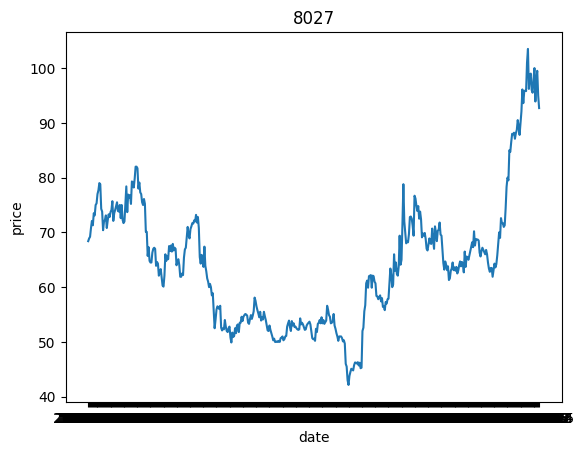

In [84]:
import matplotlib.pyplot as plt

dates = [row[0] for row in price_np]
values = [row[1] for row in price_np]

# 繪製折線圖
plt.plot(dates, values)

# 添加標籤和標題
plt.xlabel('date')
plt.ylabel('price')
plt.title(stock_id)



plt.show()
